In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(123)  # for reproducibility

In [3]:
asample2 = pd.read_csv("../data/asample2_withlag.csv")
asample2

,Cm_ltotalincome,Cm_lhourlywage,Cm_lfamilyincome,Cm_pemployed,Cm_sei,flag_unemp,Bset1_year1,Bset1_doi_employed1,Bset1_doi_employedmf1,Bset1_doi_hours_worked1,...,Aset1_Motherocc2_1979_4,Aset1_Motherocc2_1979_5,Aset1_Motherocc2_1979_7,Aset1_Motherocc2_1979_8,Aset1_Motherocc2_1979_9,Aset1_Motherocc2_1979_10,Aset1_mfFatherocc2_1979_0,Aset1_mfFatherocc2_1979_1,Aset1_mfMotherocc2_1979_0,Aset1_mfMotherocc2_1979_1
0,4.217487,1.977451,9.881452,0.666667,22.100000,0,1984,1,0,2,...,0,0,0,0,0,0,1,0,1,0
1,5.129690,1.991274,10.861930,1.000000,35.947498,0,1987,0,0,0,...,0,0,0,0,0,1,1,0,1,0
2,10.969552,3.398430,11.380778,1.000000,39.470001,0,1986,1,0,2,...,1,0,0,0,0,0,1,0,1,0
3,6.615533,2.511609,10.002362,0.333333,28.196667,0,1990,1,0,1,...,1,0,0,0,0,0,0,1,1,0
4,10.207645,2.567574,10.332740,1.000000,42.114998,0,1984,1,0,2,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7458,9.654572,1.816562,9.763045,1.000000,48.759998,0,1987,1,0,2,...,0,0,0,0,0,0,1,0,1,0
7459,0.000000,1.405642,0.000000,0.000000,15.074862,1,1982,0,0,0,...,0,0,0,0,0,0,1,0,1,0
7460,9.327805,2.223070,10.282804,1.000000,16.370001,0,1984,0,0,0,...,0,0,0,0,0,0,1,0,1,0
7461,10.226488,2.260700,10.944498,1.000000,18.678333,0,1988,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [4]:
# need to subsample data 

samp = asample2.loc[np.random.choice(asample2.index, 5, replace=False)]

In [5]:
samp

,Cm_ltotalincome,Cm_lhourlywage,Cm_lfamilyincome,Cm_pemployed,Cm_sei,flag_unemp,Bset1_year1,Bset1_doi_employed1,Bset1_doi_employedmf1,Bset1_doi_hours_worked1,...,Aset1_Motherocc2_1979_4,Aset1_Motherocc2_1979_5,Aset1_Motherocc2_1979_7,Aset1_Motherocc2_1979_8,Aset1_Motherocc2_1979_9,Aset1_Motherocc2_1979_10,Aset1_mfFatherocc2_1979_0,Aset1_mfFatherocc2_1979_1,Aset1_mfMotherocc2_1979_0,Aset1_mfMotherocc2_1979_1
6007,3.478873,2.721691,11.407592,0.333333,39.360001,0,1983,0,0,0,...,0,0,0,0,0,0,1,0,1,0
5233,4.314958,1.426712,9.432748,1.000000,23.620001,0,1987,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2972,11.384829,3.612935,11.891068,1.000000,71.513336,0,1984,1,0,2,...,0,0,0,0,0,0,1,0,1,0
6915,7.071365,2.909056,10.789304,0.500000,28.780001,0,1989,1,0,2,...,0,0,0,0,0,0,1,0,1,0
1852,9.700597,2.250909,10.394351,0.666667,26.931667,0,1985,1,0,2,...,0,0,0,0,0,0,0,1,0,1


In [6]:

print(asample2.dtypes)

Cm_ltotalincome              float64
Cm_lhourlywage               float64
Cm_lfamilyincome             float64
Cm_pemployed                 float64
Cm_sei                       float64
                              ...   
Aset1_Motherocc2_1979_10       int64
Aset1_mfFatherocc2_1979_0      int64
Aset1_mfFatherocc2_1979_1      int64
Aset1_mfMotherocc2_1979_0      int64
Aset1_mfMotherocc2_1979_1      int64
Length: 4258, dtype: object


In [12]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error

In [13]:
outcome = "Cm_lhourlywage"

predictors = [col for col in asample2.columns if "Aset" in col or "Bset" in col]

X = asample2[predictors]
y = asample2[outcome]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

In [15]:
y_mean = np.mean(y_train)
null_preds = np.full_like(y_test, y_mean)
null_mse = mean_squared_error(y_test, null_preds)

In [16]:
model = xgb.XGBRegressor(
    n_estimators=90,
    max_depth=2,
    learning_rate=0.3,
    objective="reg:squarederror",
    verbosity=0
)

In [17]:
model.fit(X_train, y_train)

preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)

r2 = 1 - mse / null_mse
print("R2:", r2)

# exactly the same as in paper :D

R2: 0.530901142121032


In [21]:
# now wrap in fucnt for different amounts of data
samp_size = [int(len(X_train) * p) for p in np.linspace(0.1, 1.0, 10)]
samp_size

[522, 1044, 1567, 2089, 2612, 3134, 3656, 4179, 4701, 5224]

In [28]:
samples = []
results = []

for s in samp_size:
    samp = X_train.sample(n=s, replace=False)
    y_samp = y_train.loc[samp.index]
    
    model.fit(samp, y_samp)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)

    r2 = 1 - mse / null_mse
    
    results.append({
        "n_samples": s,
        "mse": mse,
        "r2": r2
    })


In [29]:
results_df = pd.DataFrame(results)

In [30]:
results_df

,n_samples,mse,r2
0,522,0.210399,0.446017
1,1044,0.209693,0.447877
2,1567,0.191733,0.495165
3,2089,0.189681,0.500568
4,2612,0.182543,0.519362
5,3134,0.181870,0.521134
6,3656,0.184664,0.513778
7,4179,0.181621,0.521791
8,4701,0.177980,0.531378
9,5224,0.178161,0.530901


<Axes: xlabel='n_samples'>

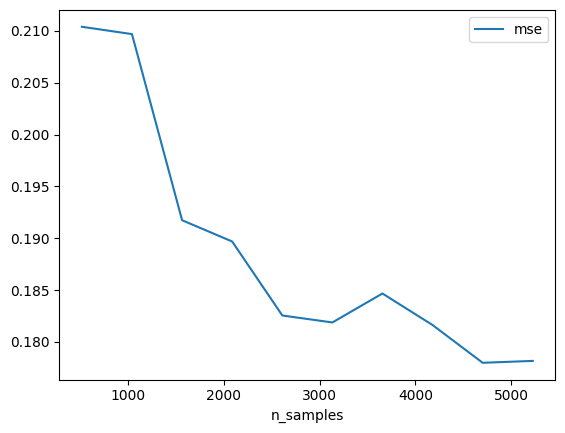

In [31]:
results_df.plot(x="n_samples", y="mse")

<Axes: xlabel='n_samples'>

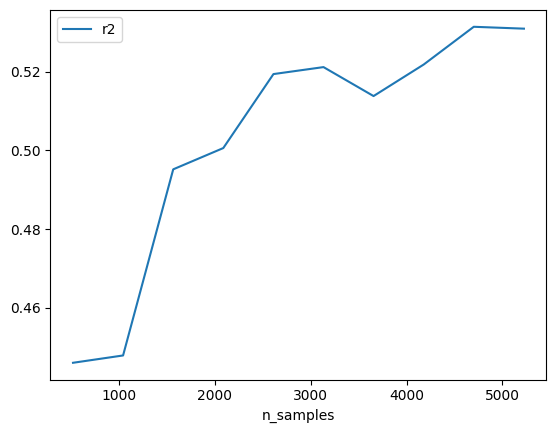

In [32]:
results_df.plot(x="n_samples", y="r2")

<Axes: xlabel='n_samples'>

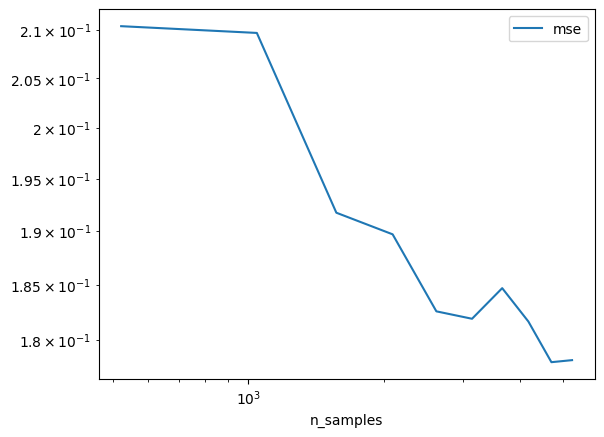

In [33]:
results_df.plot(loglog=True, x='n_samples', y='mse')

In [34]:
def power_law(n, C, alpha, epsilon):
    return C* n **(-alpha) + epsilon

In [36]:
from scipy.optimize import curve_fit

n = results_df["n_samples"].values
mse = results_df["mse"].values

p0 = [
    max(mse) - min(mse),
    0.5,
    min(mse)
]

params, _ = curve_fit(power_law, n, mse, p0=p0, maxfev=10000)

C_hat, alpha_hat, epsilon_hat = params

In [37]:
print("C:", C_hat)
print("alpha:", alpha_hat)
print("epsilon (asymptote):", epsilon_hat)

C: 0.3329378444106383
alpha: 0.09467893323511109
epsilon (asymptote): 0.028919867894147244


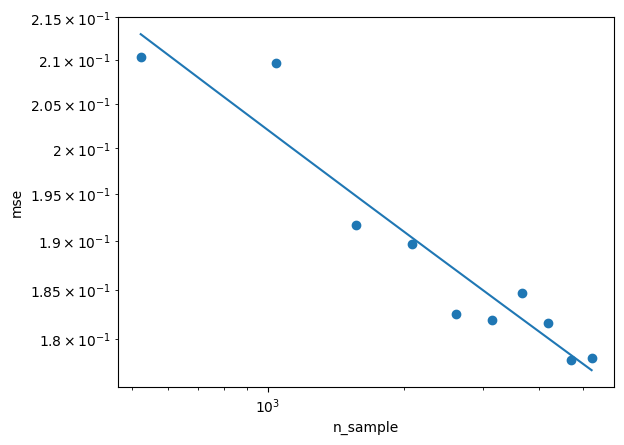

In [40]:
import matplotlib.pyplot as plt

n_smooth = np.linspace(min(n), max(n), 200)

plt.scatter(n, mse, label="data")
plt.plot(n_smooth, power_law(n_smooth, *params), label="fit")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("n_sample")
plt.ylabel("mse")
plt.show()

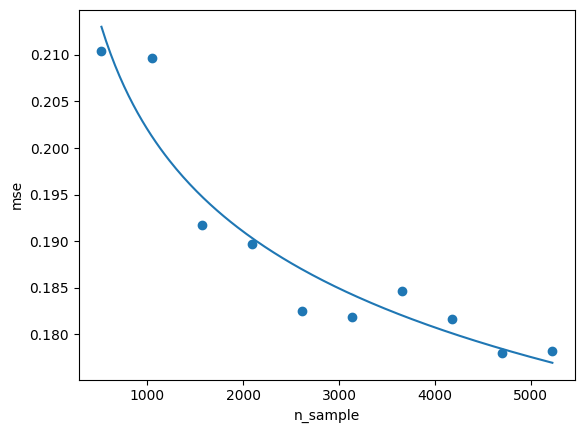

In [41]:
plt.scatter(n, mse, label="data")
plt.plot(n_smooth, power_law(n_smooth, *params), label="fit")

plt.xlabel("n_sample")
plt.ylabel("mse")
plt.show()

In [ ]:
the 